# Customer Churn Prediction Project

## Objective

The primary objective of this project is to develop a robust machine learning model capable of accurately predicting customer churn based on historical customer data. The model aims to identify customers who are likely to discontinue using the service, enabling businesses to take proactive measures to retain them.

This project also focuses on comparing multiple machine learning and deep learning algorithms to determine the most effective model based on performance metrics such as ROC-AUC and F1-score. Additionally, the goal is to build a deployment-ready solution that can be integrated into real-world business systems for continuous monitoring and prediction of customer churn.

---

## Business Problem

Customer churn is one of the most critical challenges faced by subscription-based and service-oriented businesses. Acquiring new customers is significantly more expensive than retaining existing ones, making customer retention a key driver of profitability and long-term growth.

In a highly competitive market, businesses often struggle to identify customers who are at risk of leaving. Without early detection, companies lose valuable customers, leading to reduced revenue and increased acquisition costs.

This project addresses this problem by leveraging data-driven techniques to predict churn behavior. By identifying high-risk customers in advance, organizations can implement targeted retention strategies such as personalized offers, improved customer support, and engagement initiatives. This not only reduces churn rate but also enhances customer satisfaction and lifetime value.

### Importing Libraries

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import mysql.connector

### Connecting My SQL to Jupiter Notebook

In [2]:
connect = mysql.connector.connect(
    host="localhost",
    user="root",
    password="11112004",
    database="churn_db")
query = "Select * from customers"

### Loading Data

In [3]:
df = pd.read_sql(query,connect)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Basic Data Understanding 

In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Preprocessing

- Handling missing values
- Exploratory Data Analysis
- Encoding categorical variables
- Feature scaling
- Train-test split


### Data Cleanning

#During data understanding step we got known a problem that the datatype of the TotalCharges is object even though the data inside the column is numeric

In [7]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["MonthlyCharges"]*df["tenure"],inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

#In the Data cleanning step we change the data type of TotalCharges and after that we check so null values and duplicates in data 
we got know that there are no duplicates in data but there are null values in TotalCharges column of the dataset so we fill with 
MonthlyCharges multiplying by tenure (how long customer has been with the company).

### Understanding Target Variable

In [11]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#In this step we understand that the datasets is Imbalanced 

### Exploratory Data Analysis (EDA)

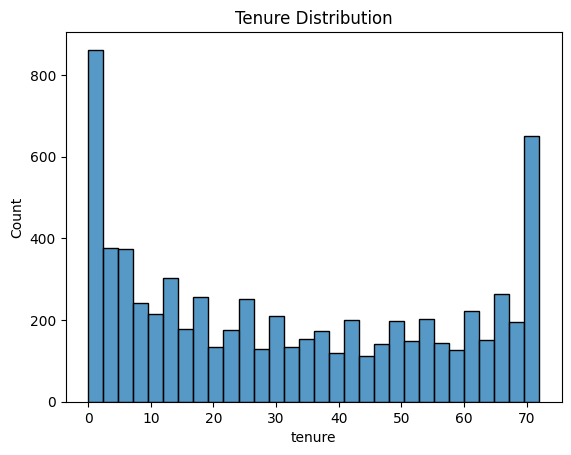

In [12]:
sns.histplot(df["tenure"],bins=30)
plt.title("Tenure Distribution")
plt.show()

#In this graph we got known that most customers are in the early tenure range, indicating  many new customers in the business

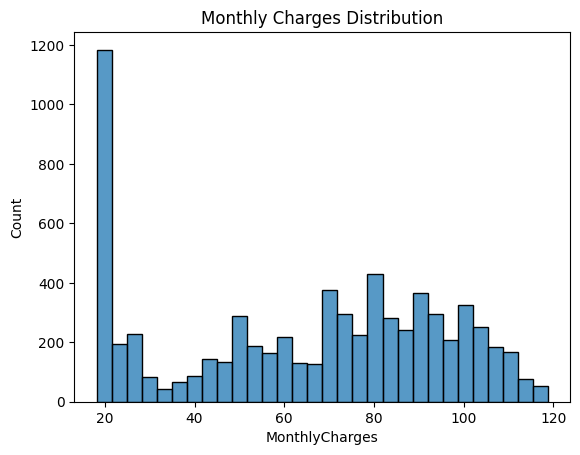

In [13]:
sns.histplot(df["MonthlyCharges"],bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

#In this graph we got to known that most charges are spread across wide range, with more customers paying lower to mid-range charges

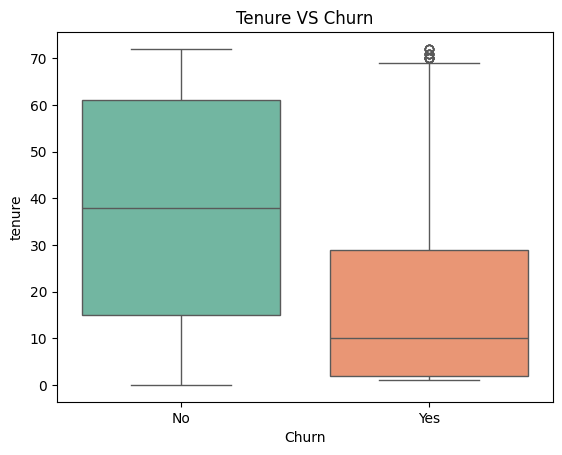

In [14]:
sns.boxplot(x="Churn",y="tenure",data=df,palette="Set2")
plt.title("Tenure VS Churn")
plt.show()

#In ths graph we got to known that customers who churn typically have much lower tenure compared to customers who stay.

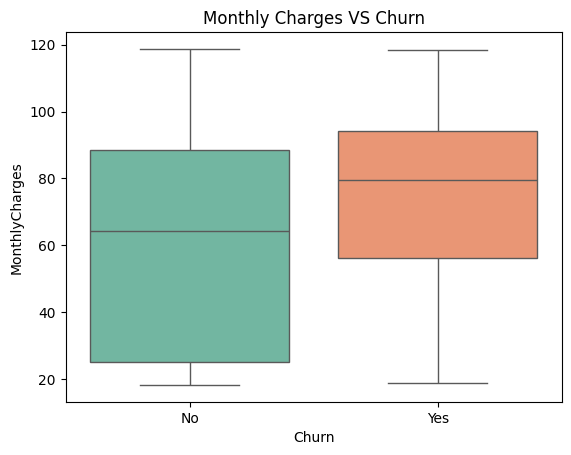

In [15]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df,palette="Set2")
plt.title("Monthly Charges VS Churn")
plt.show()

#In this graph we got to known that churned customers generally have higher monthly charges than retained customers

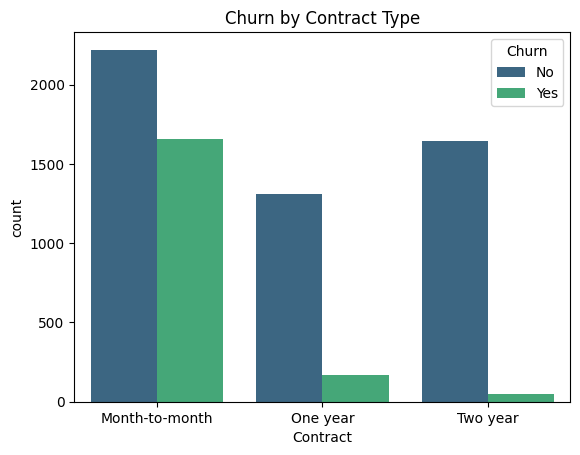

In [16]:
sns.countplot(x="Contract",hue="Churn",data=df,palette="viridis")
plt.title("Churn by Contract Type")
plt.show()

#In this plot we got known that Month-to-month contract customers have significantly higher churn compared to long-tern contracts 

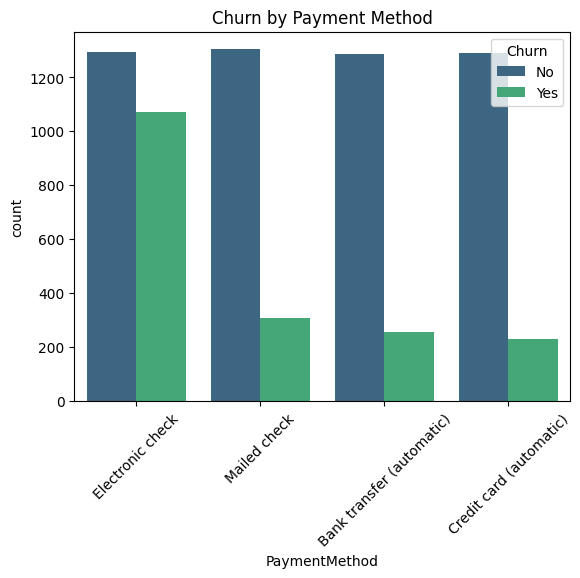

In [17]:
sns.countplot(x="PaymentMethod",hue="Churn",data=df,palette="viridis")
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

#In this garph we got to kown that Customers using electronic check churn more than those using automatic payment methods.

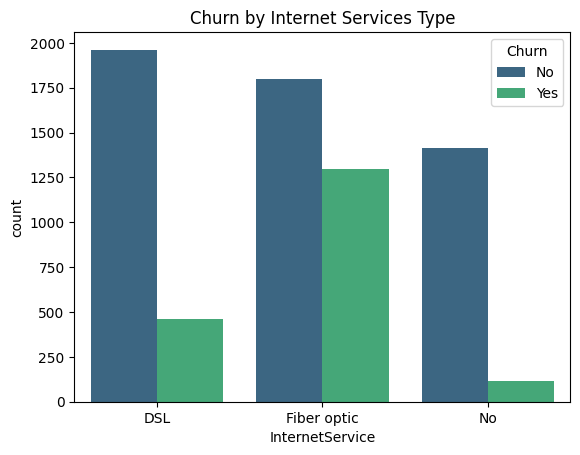

In [18]:
sns.countplot(x="InternetService",hue="Churn",data=df,palette="viridis")
plt.title("Churn by Internet Services Type")
plt.show()

#In this garph we got to known this that Customers using fiber optic internet service show higher churn compared to DSL users.

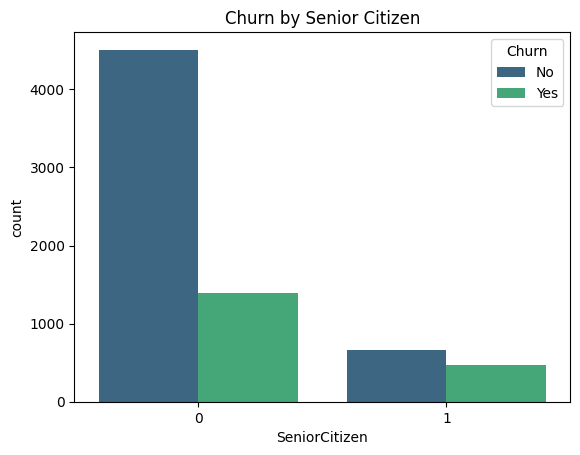

In [19]:
sns.countplot(x="SeniorCitizen",hue="Churn",data=df,palette="viridis")
plt.title("Churn by Senior Citizen")
plt.show()

#In this graph we got known that Senior Citizen show slightly higher churn compared to non-senior customers.

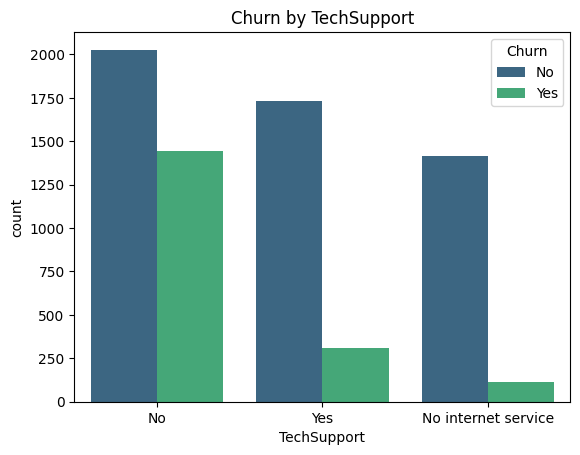

In [20]:
sns.countplot(x="TechSupport",hue="Churn",data=df,palette="viridis")
plt.title("Churn by TechSupport")
plt.show()

#In this garph we got to known that Customers without tech support churn more than those who have it.

### Feature Engineering

In [21]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [22]:
x = df.drop(["customerID","Churn"],axis=1)
y = df["Churn"]

### Encoding

In [23]:
cat_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(include=["int64","float64"]).columns

In [24]:
x=pd.get_dummies(x,columns=cat_cols,drop_first=True)

### Train-Test-Split

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

### Scaling

In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])

### Handling Imbalanced Data

SMOTE is applied to balance minority class and improve recall for churn prediction.

In [27]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sm,y_train_sm = smote.fit_resample(x_train,y_train)

# Model Training

Multiple models are trained:
- Logistic Regression
- KNN
- SVM
- Decision Tree
- Random Forest
- XGBoost
- ANN

Evaluation metrics:
- Accuracy
- F1 Score
- ROC-AUC (primary metric)

## Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
lr=LogisticRegression(max_iter=100)
lr.fit(x_train_sm,y_train_sm)

cv_scores = cross_val_score(lr,x_train_sm,y_train_sm,cv=5,scoring="roc_auc")
print("CV Score:",cv_scores.mean())

y_pred_lr = lr.predict(x_test)
y_prob_lr = lr.predict_proba(x_test)[:,1]

CV Score: 0.8853993995054144


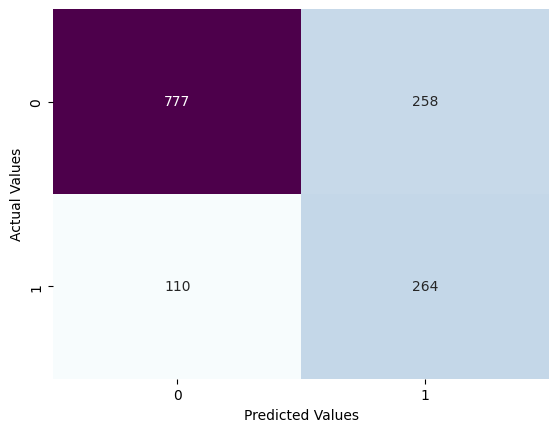

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1035
           1       0.51      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409

Accuracy of the model:  0.7388218594748048
F1-Score of the model:  0.5892857142857143
ROC-AUC-Score of the model:  0.8209667002505876


In [29]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_lr))

lr_acc=accuracy_score(y_test,y_pred_lr)
print("Accuracy of the model: ",lr_acc)
lr_f1_score=f1_score(y_test,y_pred_lr)
print("F1-Score of the model: ",lr_f1_score)
lr_auc = roc_auc_score(y_test,y_prob_lr)
print("ROC-AUC-Score of the model: ",lr_auc)

## KNN

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_sm,y_train_sm)

cv_scores = cross_val_score(knn,x_train_sm,y_train_sm,cv=5,scoring="roc_auc")
print("CV Score:",cv_scores.mean())

y_pred_knn = knn.predict(x_test)
y_prob_knn = knn.predict_proba(x_test)[:,1]

CV Score: 0.8784096988050865


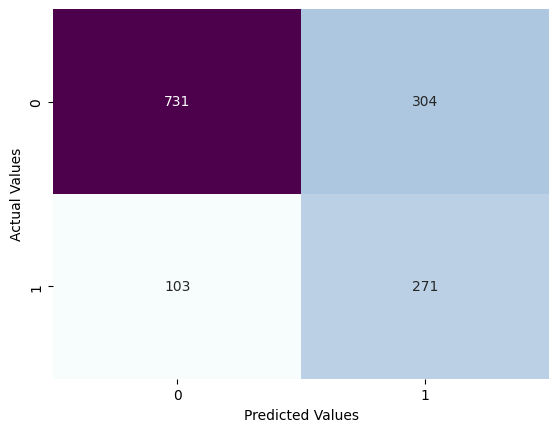

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78      1035
           1       0.47      0.72      0.57       374

    accuracy                           0.71      1409
   macro avg       0.67      0.72      0.68      1409
weighted avg       0.77      0.71      0.73      1409

Accuracy of the model:  0.7111426543647977
F1-Score of the model:  0.571127502634352
ROC-AUC-Score of the model:  0.7834121263788784


In [31]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_knn)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_knn))

knn_acc=accuracy_score(y_test,y_pred_knn)
print("Accuracy of the model: ",knn_acc)
knn_f1_score=f1_score(y_test,y_pred_knn)
print("F1-Score of the model: ",knn_f1_score)
knn_auc = roc_auc_score(y_test,y_prob_knn)
print("ROC-AUC-Score of the model: ",knn_auc)

## SVM

In [32]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
svm = SVC(kernel = "rbf",probability=True,random_state=42)
svm.fit(x_train_sm,y_train_sm)

cv_scores = cross_val_score(svm,x_train_sm,y_train_sm,cv=5,scoring="roc_auc")
print("CV Score:",cv_scores.mean())


y_pred_svm = svm.predict(x_test)
y_prob_svm = svm.predict_proba(x_test)[:,1]

CV Score: 0.879821672012483


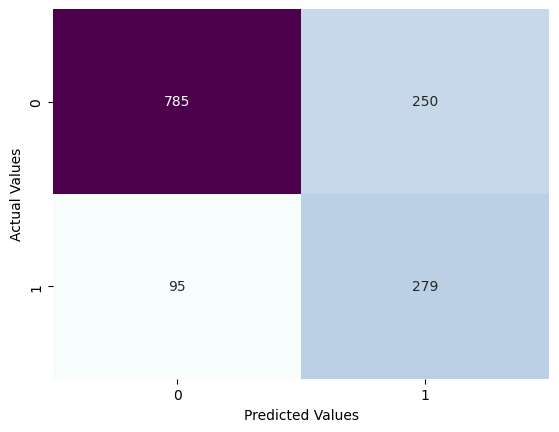

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Accuracy of the model:  0.7551454932576295
F1-Score of the model:  0.6179401993355482
ROC-AUC-Score of the model:  0.8157392337699242


In [33]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_svm)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_svm))

svm_acc=accuracy_score(y_test,y_pred_svm)
print("Accuracy of the model: ",svm_acc)
svm_f1_score=f1_score(y_test,y_pred_svm)
print("F1-Score of the model: ",svm_f1_score)
svm_auc = roc_auc_score(y_test,y_prob_svm)
print("ROC-AUC-Score of the model: ",svm_auc)

## Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
dt = DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train_sm,y_train_sm)

cv_scores = cross_val_score(dt,x_train_sm,y_train_sm,cv=5,scoring="roc_auc")
print("CV Score:",cv_scores.mean())

y_pred_dt = dt.predict(x_test)
y_prob_dt = dt.predict_proba(x_test)[:,1]

CV Score: 0.8418877218170847


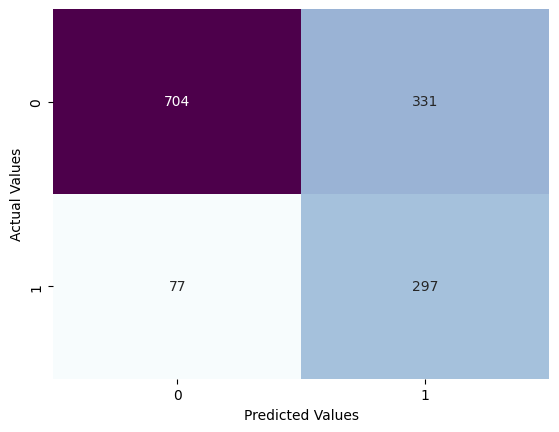

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78      1035
           1       0.47      0.79      0.59       374

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.79      0.71      0.73      1409

Accuracy of the model:  0.7104329311568488
F1-Score of the model:  0.592814371257485
ROC-AUC-Score of the model:  0.8225038104833502


In [35]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_dt)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_dt))

dt_acc=accuracy_score(y_test,y_pred_dt)
print("Accuracy of the model: ",dt_acc)
dt_f1_score=f1_score(y_test,y_pred_dt)
print("F1-Score of the model: ",dt_f1_score)
dt_auc = roc_auc_score(y_test,y_prob_dt)
print("ROC-AUC-Score of the model: ",dt_auc)

## Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
rf = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)
rf.fit(x_train_sm,y_train_sm)

cv_scores = cross_val_score(rf,x_train_sm,y_train_sm,cv=5,scoring="roc_auc")
print("CV Score:",cv_scores.mean())

y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:,1]

CV Score: 0.8968495943390874


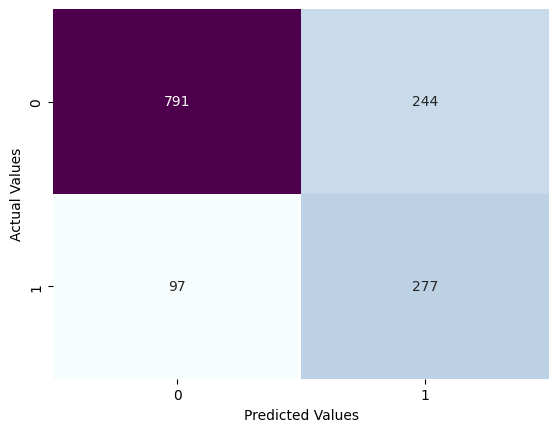

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Accuracy of the model:  0.7579843860894251
F1-Score of the model:  0.6189944134078212
ROC-AUC-Score of the model:  0.8388152626004289


In [37]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_rf))

rf_acc=accuracy_score(y_test,y_pred_rf)
print("Accuracy of the model: ",rf_acc)
rf_f1_score=f1_score(y_test,y_pred_rf)
print("F1-Score of the model: ",rf_f1_score)
rf_auc = roc_auc_score(y_test,y_prob_rf)
print("ROC-AUC-Score of the model: ",rf_auc)

## XGBoost

In [38]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
xgb = XGBClassifier(random_state=42)
xgb.fit(x_train_sm,y_train_sm)

cv_scores = cross_val_score(xgb,x_train_sm,y_train_sm,cv=5,scoring="roc_auc")
print("CV Score:",cv_scores.mean())

y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:,1]

CV Score: 0.9082799944000646


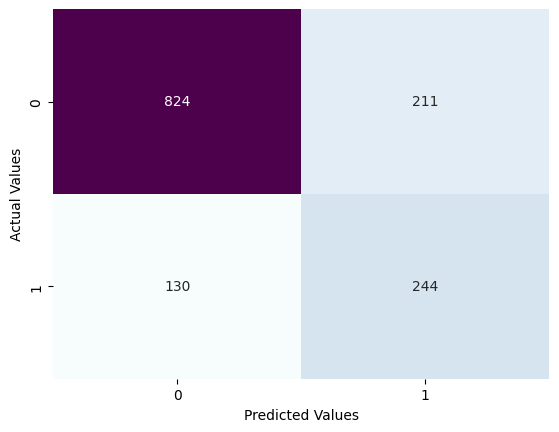

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1035
           1       0.54      0.65      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.76      1409

Accuracy of the model:  0.7579843860894251
F1-Score of the model:  0.5886610373944512
ROC-AUC-Score of the model:  0.8054496370353149


In [39]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_xgb)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_xgb))

xgb_acc=accuracy_score(y_test,y_pred_xgb)
print("Accuracy of the model: ",xgb_acc)
xgb_f1_score=f1_score(y_test,y_pred_xgb)
print("F1-Score of the model: ",xgb_f1_score)
xgb_auc = roc_auc_score(y_test,y_prob_xgb)
print("ROC-AUC-Score of the model: ",xgb_auc)

## ANN

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model_dl = Sequential()
model_dl.add(Dense(16,input_dim=x_train_sm.shape[1],activation="relu"))
model_dl.add(Dense(8,activation="relu"))
model_dl.add(Dense(1,activation="sigmoid"))

model_dl.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
early_stop = EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)

history = model_dl.fit(x_train_sm,y_train_sm,epochs=30,batch_size=32,validation_split=0.2,callbacks=[early_stop],verbose=1)

y_pred_prob_dl = model_dl.predict(x_test)
y_pred_dl = (y_pred_prob_dl>0.5).astype(int)

Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6593 - loss: 0.5979 - val_accuracy: 0.6419 - val_loss: 0.7731
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7697 - loss: 0.4850 - val_accuracy: 0.7228 - val_loss: 0.6420
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7768 - loss: 0.4715 - val_accuracy: 0.7005 - val_loss: 0.6650
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7765 - loss: 0.4660 - val_accuracy: 0.6914 - val_loss: 0.6785
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7783 - loss: 0.4615 - val_accuracy: 0.6793 - val_loss: 0.6899
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


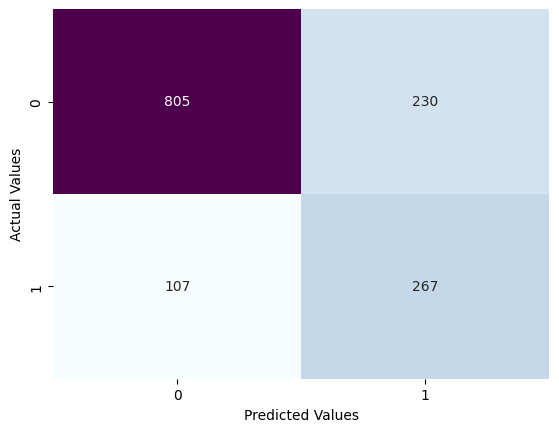

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Accuracy of the model:  0.7608232789212207
F1-Score of the model:  0.6130884041331802
ROC-AUC-Score of the model:  0.8341651812240047


In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_dl)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_dl))

dl_acc=accuracy_score(y_test,y_pred_dl)
print("Accuracy of the model: ",dl_acc)
dl_f1_score=f1_score(y_test,y_pred_dl)
print("F1-Score of the model: ",dl_f1_score)
dl_auc = roc_auc_score(y_test,y_pred_prob_dl)
print("ROC-AUC-Score of the model: ",dl_auc)

# Model Comparison

All models are compared based on ROC-AUC score to select the best performing model.

In [43]:
results = []
results.append(["Logistic",lr_acc,lr_f1_score,lr_auc])
results.append(["KNN",knn_acc,knn_f1_score,knn_auc])
results.append(["SVM",svm_acc,svm_f1_score,svm_auc])
results.append(["Decision Tree",dt_acc,dt_f1_score,dt_auc])
results.append(["Random Forest",rf_acc,rf_f1_score,rf_auc])
results.append(["XGBoost",xgb_acc,xgb_f1_score,xgb_auc])
results.append(["ANN",dl_acc,dl_f1_score,dl_auc])

df1 = pd.DataFrame(results,columns=["Model","Accuracy","F1 Score","ROC-AUC"])
print(df1.sort_values(by="ROC-AUC",ascending=False))

           Model  Accuracy  F1 Score   ROC-AUC
4  Random Forest  0.757984  0.618994  0.838815
6            ANN  0.760823  0.613088  0.834165
3  Decision Tree  0.710433  0.592814  0.822504
0       Logistic  0.738822  0.589286  0.820967
2            SVM  0.755145  0.617940  0.815739
5        XGBoost  0.757984  0.588661  0.805450
1            KNN  0.711143  0.571128  0.783412


## Hyperparameter Tuning

GridSearchCV is used to optimize Random Forest parameters to improve performance.


In [44]:
from sklearn.model_selection import GridSearchCV
param_grid = {"n_estimators" : [100,200],
              "max_depth"    : [5,8,10],
              "min_samples_split" : [5,10],
              "min_samples_leaf"  : [2,4]}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring="roc_auc",n_jobs=-1)
grid_rf.fit(x_train_sm,y_train_sm)
best_rf = grid_rf.best_estimator_
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


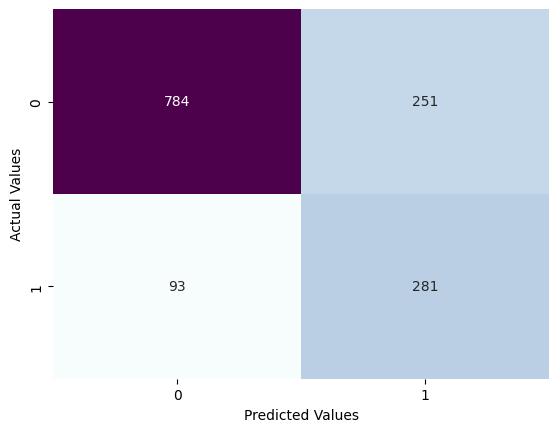

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Accuracy of the model:  0.7558552164655784
F1-Score of the model:  0.6203090507726269
ROC-AUC-Score of the model:  0.8385788834637938


In [45]:
y_pred_best_rf = best_rf.predict(x_test)
y_prob_best_rf = best_rf.predict_proba(x_test)[:,1]

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score
cfm=confusion_matrix(y_test,y_pred_best_rf)
sns.heatmap(cfm,annot=True,fmt="g",cbar=False,cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

print("Classification report:")

print(classification_report(y_test,y_pred_best_rf))

best_rf_acc=accuracy_score(y_test,y_pred_best_rf)
print("Accuracy of the model: ",best_rf_acc)
best_rf_f1_score=f1_score(y_test,y_pred_best_rf)
print("F1-Score of the model: ",best_rf_f1_score)
best_rf_auc = roc_auc_score(y_test,y_prob_best_rf)
print("ROC-AUC-Score of the model: ",best_rf_auc)

## Final Model Selection

Random Forest is selected as the final model based on highest ROC-AUC and balanced F1 score.

The tuned model provides better generalization on unseen data.

## Model Saving

The final model, scaler, and feature columns are saved using joblib for deployment.

In [49]:
import joblib
joblib.dump(best_rf,"churn_model.pkl")
joblib.dump(scaler,"scaler.pkl")
x_train_columns=x_train.columns
joblib.dump(x_train_columns,"training_columns.pkl")

['training_columns.pkl']

# Conclusion

In this project, multiple machine learning and deep learning models were developed and evaluated to predict customer churn. Various preprocessing techniques such as feature encoding, scaling, and handling class imbalance using SMOTE were applied to improve model performance.

Among all the models tested, Random Forest emerged as the best-performing model, achieving the highest ROC-AUC score along with a well-balanced F1-score. This indicates that the model is capable of effectively distinguishing between customers who are likely to churn and those who are not, even in the presence of imbalanced data.

The results demonstrate that ensemble learning methods like Random Forest can provide strong predictive performance while maintaining stability and interpretability. Although deep learning models such as ANN were also explored, they did not significantly outperform traditional machine learning models for this dataset.

This project successfully provides a scalable and deployment-ready solution that can be integrated into business workflows to identify high-risk customers. By leveraging these insights, organizations can take proactive steps to reduce churn, improve customer retention, and increase overall profitability.

---

## Future Scope

- Integration of real-time prediction systems using APIs
- Enhancement of model performance using advanced boosting techniques
- Incorporation of customer behavioral and transactional data
- Deployment of a GenAI-based explanation system to provide human-like insights for predictions
- Continuous model monitoring and retraining for improved accuracy over time